#  Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

# This will open a file picker
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving BANK FULL.xlsx to BANK FULL.xlsx
User uploaded file "BANK FULL.xlsx" with length 3695241 bytes


In [ ]:
import pandas as pd

# Load the uploaded Excel file
file_name = 'BANK FULL.xlsx'
df = pd.read_excel(file_name)

# Display the first few rows and basic info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         45211 non-null  int64  
 1   job         45211 non-null  object 
 2   marital     45211 non-null  object 
 3   education   45211 non-null  object 
 4   default     45211 non-null  object 
 5   balance     45211 non-null  int64  
 6   housing     45211 non-null  object 
 7   loan        45211 non-null  object 
 8   contact     45211 non-null  object 
 9   day         45211 non-null  int64  
 10  month       45211 non-null  object 
 11  duration    45211 non-null  int64  
 12  campaign    45211 non-null  int64  
 13  pdays       45211 non-null  int64  
 14  previous    45211 non-null  int64  
 15  poutcome    45211 non-null  object 
 16  y           45211 non-null  object 
 17  Int.Rate09  45211 non-null  float64
 18  Int.R08     45211 non-null  float64
dtypes: float64(2), int64(7), 

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Int.Rate09,Int.R08
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no,1.71,4.38
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes,1.71,4.38
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes,1.71,4.38
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no,1.71,4.38
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no,1.71,4.38


In [ ]:
df = df.drop(columns=['Int.R08'])
print("Column 'Int.R08' dropped. Updated columns:")
print(df.columns)

Column 'Int.R08' dropped. Updated columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'Int.Rate09'],
      dtype='object')


In [ ]:
df = df.drop(columns=['day', 'month', 'duration', 'campaign'])
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,pdays,previous,poutcome,y,Int.Rate09
0,18,student,single,primary,no,1944,no,no,telephone,-1,0,unknown,no,1.71
1,18,student,single,unknown,no,108,no,no,cellular,-1,0,unknown,yes,1.71
2,18,student,single,primary,no,608,no,no,cellular,-1,0,unknown,yes,1.71
3,18,student,single,unknown,no,35,no,no,telephone,-1,0,unknown,no,1.71
4,18,student,single,secondary,no,5,no,no,cellular,-1,0,unknown,no,1.71


In [ ]:
def categorize_pdays(days):
    if days == -1:
        return 'Never Contacted'
    elif 1 <= days <= 30:
        return 'Recent Engagement'
    elif 31 <= days <= 180:
        return 'Moderate Engagement'
    elif 181 <= days <= 365:
        return 'Low Engagement'
    elif days > 365:
        return 'Dormant Customers'
    else:
        return 'Other' # Handle cases if 0 or other unexpected values exist

df['pdays_category'] = df['pdays'].apply(categorize_pdays)

# Display the mapping results
display(df[['pdays', 'pdays_category']].drop_duplicates().sort_values(by='pdays').head(10))
display(df['pdays_category'].value_counts())

,pdays,pdays_category
0,-1,Never Contacted
5243,1,Recent Engagement
1759,2,Recent Engagement
11084,3,Recent Engagement
10608,4,Recent Engagement
1766,5,Recent Engagement
1784,6,Recent Engagement
14117,7,Recent Engagement
4744,8,Recent Engagement
8585,9,Recent Engagement


,count
pdays_category,
Never Contacted,36954
Low Engagement,4416
Moderate Engagement,3010
Dormant Customers,643
Recent Engagement,188


In [ ]:
def categorize_previous(count):
    if count == 0:
        return 'No Previous Contact'
    elif 1 <= count <= 5:
        return 'Low Previous Contact'
    elif 6 <= count <= 10:
        return 'Moderate Previous Contact'
    elif 11 <= count <= 20:
        return 'High Previous Contact'
    elif count >= 21:
        return 'Very High Previous Contact'
    else:
        return 'Other'

df['previous_category'] = df['previous'].apply(categorize_previous)

# Display the mapping results and value counts
display(df[['previous', 'previous_category']].drop_duplicates().sort_values(by='previous').head(15))
display(df['previous_category'].value_counts())

,previous,previous_category
0,0,No Previous Contact
8,1,Low Previous Contact
33,2,Low Previous Contact
42,3,Low Previous Contact
7,4,Low Previous Contact
83,5,Low Previous Contact
88,6,Moderate Previous Contact
147,7,Moderate Previous Contact
87,8,Moderate Previous Contact
432,9,Moderate Previous Contact


,count
previous_category,
No Previous Contact,36954
Low Previous Contact,7193
Moderate Previous Contact,770
High Previous Contact,239
Very High Previous Contact,55


In [ ]:
from google.colab import files

# Save the DataFrame to an Excel file
output_file = 'BANK_FULL_PROCESSED.xlsx'
df.to_excel(output_file, index=False)

# Trigger the download
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = df.drop(columns=['pdays', 'previous'])

print("Columns 'pdays' and 'previous' have been removed.")
display(df.head())
print(df.columns)

Columns 'pdays' and 'previous' have been removed.


,age,job,marital,education,default,balance,housing,loan,contact,poutcome,y,Int.Rate09,pdays_category,previous_category
0,18,student,single,primary,no,1944,no,no,telephone,unknown,no,1.71,Never Contacted,No Previous Contact
1,18,student,single,unknown,no,108,no,no,cellular,unknown,yes,1.71,Never Contacted,No Previous Contact
2,18,student,single,primary,no,608,no,no,cellular,unknown,yes,1.71,Never Contacted,No Previous Contact
3,18,student,single,unknown,no,35,no,no,telephone,unknown,no,1.71,Never Contacted,No Previous Contact
4,18,student,single,secondary,no,5,no,no,cellular,unknown,no,1.71,Never Contacted,No Previous Contact


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'poutcome', 'y', 'Int.Rate09', 'pdays_category',
       'previous_category'],
      dtype='object')


In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"Applying one-hot encoding to: {categorical_cols}")

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded dataframe
display(df_encoded.head())
print(f"New shape of the dataset: {df_encoded.shape}")

Applying one-hot encoding to: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'pdays_category', 'previous_category']


,age,balance,y,Int.Rate09,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,poutcome_success,poutcome_unknown,pdays_category_Low Engagement,pdays_category_Moderate Engagement,pdays_category_Never Contacted,pdays_category_Recent Engagement,previous_category_Low Previous Contact,previous_category_Moderate Previous Contact,previous_category_No Previous Contact,previous_category_Very High Previous Contact
0,18,1944,no,1.71,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
1,18,108,yes,1.71,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
2,18,608,yes,1.71,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
3,18,35,no,1.71,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
4,18,5,no,1.71,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False


New shape of the dataset: (45211, 36)


In [ ]:
print(df_encoded.columns.tolist())

['age', 'balance', 'y', 'Int.Rate09', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'pdays_category_Low Engagement', 'pdays_category_Moderate Engagement', 'pdays_category_Never Contacted', 'pdays_category_Recent Engagement', 'previous_category_Low Previous Contact', 'previous_category_Moderate Previous Contact', 'previous_category_No Previous Contact', 'previous_category_Very High Previous Contact']


### Final Data Preparation: Target Encoding and Splitting
We will convert the target variable `y` to binary and split the dataset into features (`X`) and target (`y`).

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Encode the target variable 'y'
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# 2. Define features (X) and target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Target variable encoded. 'yes' -> 1, 'no' -> 0.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
display(y_train.value_counts(normalize=True))

Target variable encoded. 'yes' -> 1, 'no' -> 0.
Training set shape: (36168, 35)
Testing set shape: (9043, 35)


,proportion
y,
0,0.883018
1,0.116982


### Feature Scaling: Standardization



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled using StandardScaler.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

display(X_train_scaled.head())

Features scaled using StandardScaler.
X_train_scaled shape: (36168, 35)
X_test_scaled shape: (9043, 35)


,age,balance,Int.Rate09,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,poutcome_success,poutcome_unknown,pdays_category_Low Engagement,pdays_category_Moderate Engagement,pdays_category_Never Contacted,pdays_category_Recent Engagement,previous_category_Low Previous Contact,previous_category_Moderate Previous Contact,previous_category_No Previous Contact,previous_category_Very High Previous Contact
25909,0.005612,-0.344452,0.167140,-0.52295,-0.184048,-0.167758,-0.512473,-0.230522,-0.190299,-0.316809,...,-0.185408,0.472806,-0.329593,-0.266477,0.473025,-0.065817,-0.435453,-0.131522,0.473025,-0.036072
40276,1.324274,0.220373,-0.914704,-0.52295,-0.184048,-0.167758,1.951322,-0.230522,-0.190299,-0.316809,...,-0.185408,-2.115033,3.034043,-0.266477,-2.114055,-0.065817,2.296458,-0.131522,-2.114055,-0.036072
6178,-1.030479,1.376263,-0.914704,-0.52295,-0.184048,-0.167758,1.951322,-0.230522,-0.190299,-0.316809,...,-0.185408,0.472806,-0.329593,-0.266477,0.473025,-0.065817,-0.435453,-0.131522,0.473025,-0.036072
20524,-0.276958,-0.417925,0.167140,-0.52295,-0.184048,-0.167758,1.951322,-0.230522,-0.190299,-0.316809,...,-0.185408,0.472806,-0.329593,-0.266477,0.473025,-0.065817,-0.435453,-0.131522,0.473025,-0.036072
24991,0.005612,-0.363804,-0.214687,-0.52295,-0.184048,-0.167758,1.951322,-0.230522,-0.190299,-0.316809,...,-0.185408,0.472806,-0.329593,-0.266477,0.473025,-0.065817,-0.435453,-0.131522,0.473025,-0.036072


### Model Training and Evaluation



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Logistic Regression model
# Set max_iter to prevent convergence warnings if the dataset is complex
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model using the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Prediction and Evaluation



In [ ]:
# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.68      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,7898,87
Actual 1,872,186



Accuracy: 0.8940


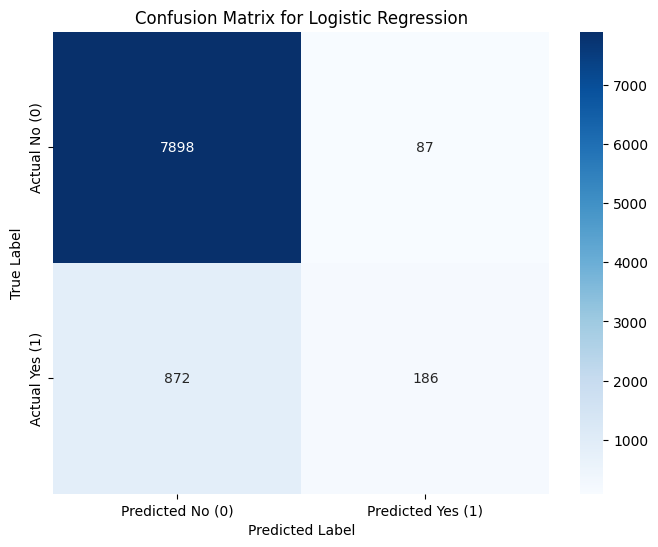

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the Confusion Matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Feature Importance Analysis for Logistic Regression



In [ ]:
# Get feature coefficients from the Logistic Regression model
coefficients = log_reg_model.coef_[0]

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Sort features by the absolute value of their coefficients
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Coefficient,Abs_Coefficient
23,contact_unknown,-0.453955,0.453955
25,poutcome_success,0.407842,0.407842
33,previous_category_No Previous Contact,-0.341314,0.341314
29,pdays_category_Never Contacted,-0.341314,0.341314
26,poutcome_unknown,0.323289,0.323289
27,pdays_category_Low Engagement,-0.289803,0.289803
20,housing_yes,-0.287222,0.287222
28,pdays_category_Moderate Engagement,-0.186007,0.186007
21,loan_yes,-0.173247,0.173247
17,education_tertiary,0.134520,0.134520


/tmp/ipykernel_816/1387150394.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(20), palette='viridis')


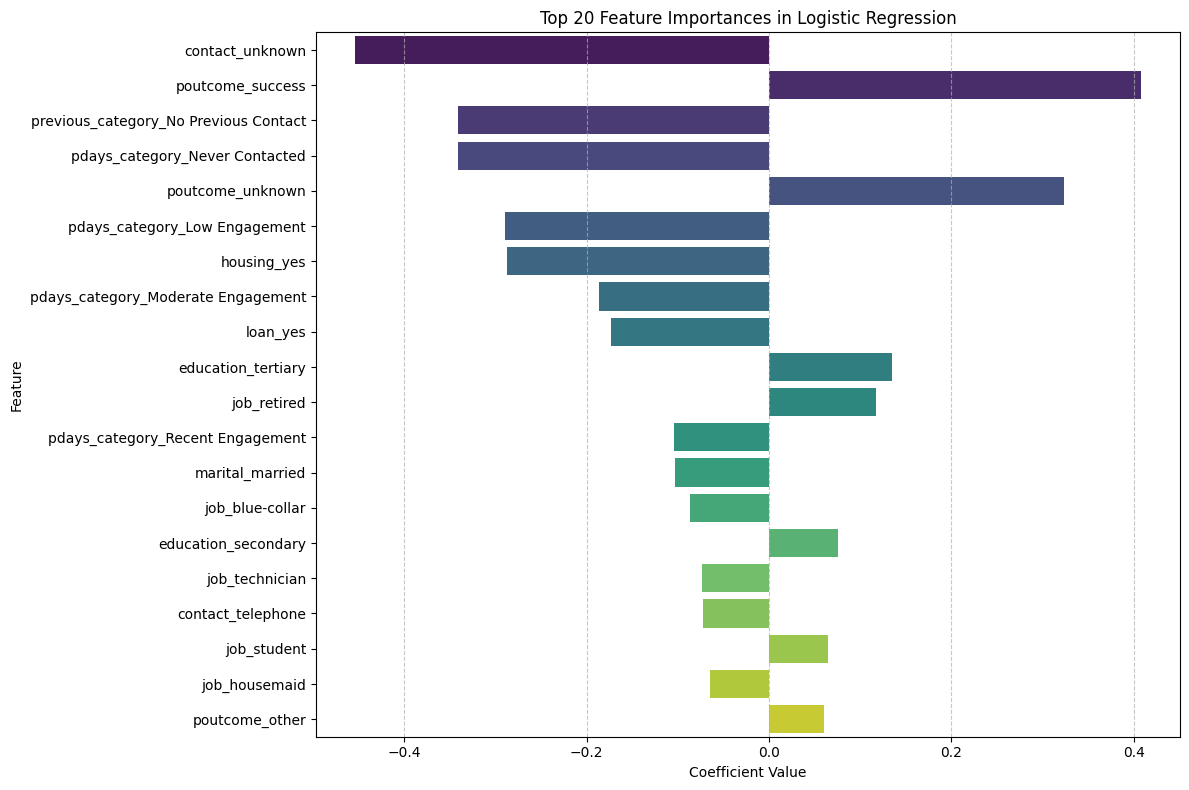

In [ ]:


# Visualize the top 20 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(20), palette='viridis')
plt.title('Top 20 Feature Importances in Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization of All Feature Importances

To provide a complete picture, here's a visualization showing the coefficients for all features present in the model. This allows for a comprehensive overview of each feature's contribution, both positive and negative, to the logistic regression model's predictions.

/tmp/ipykernel_816/489758635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


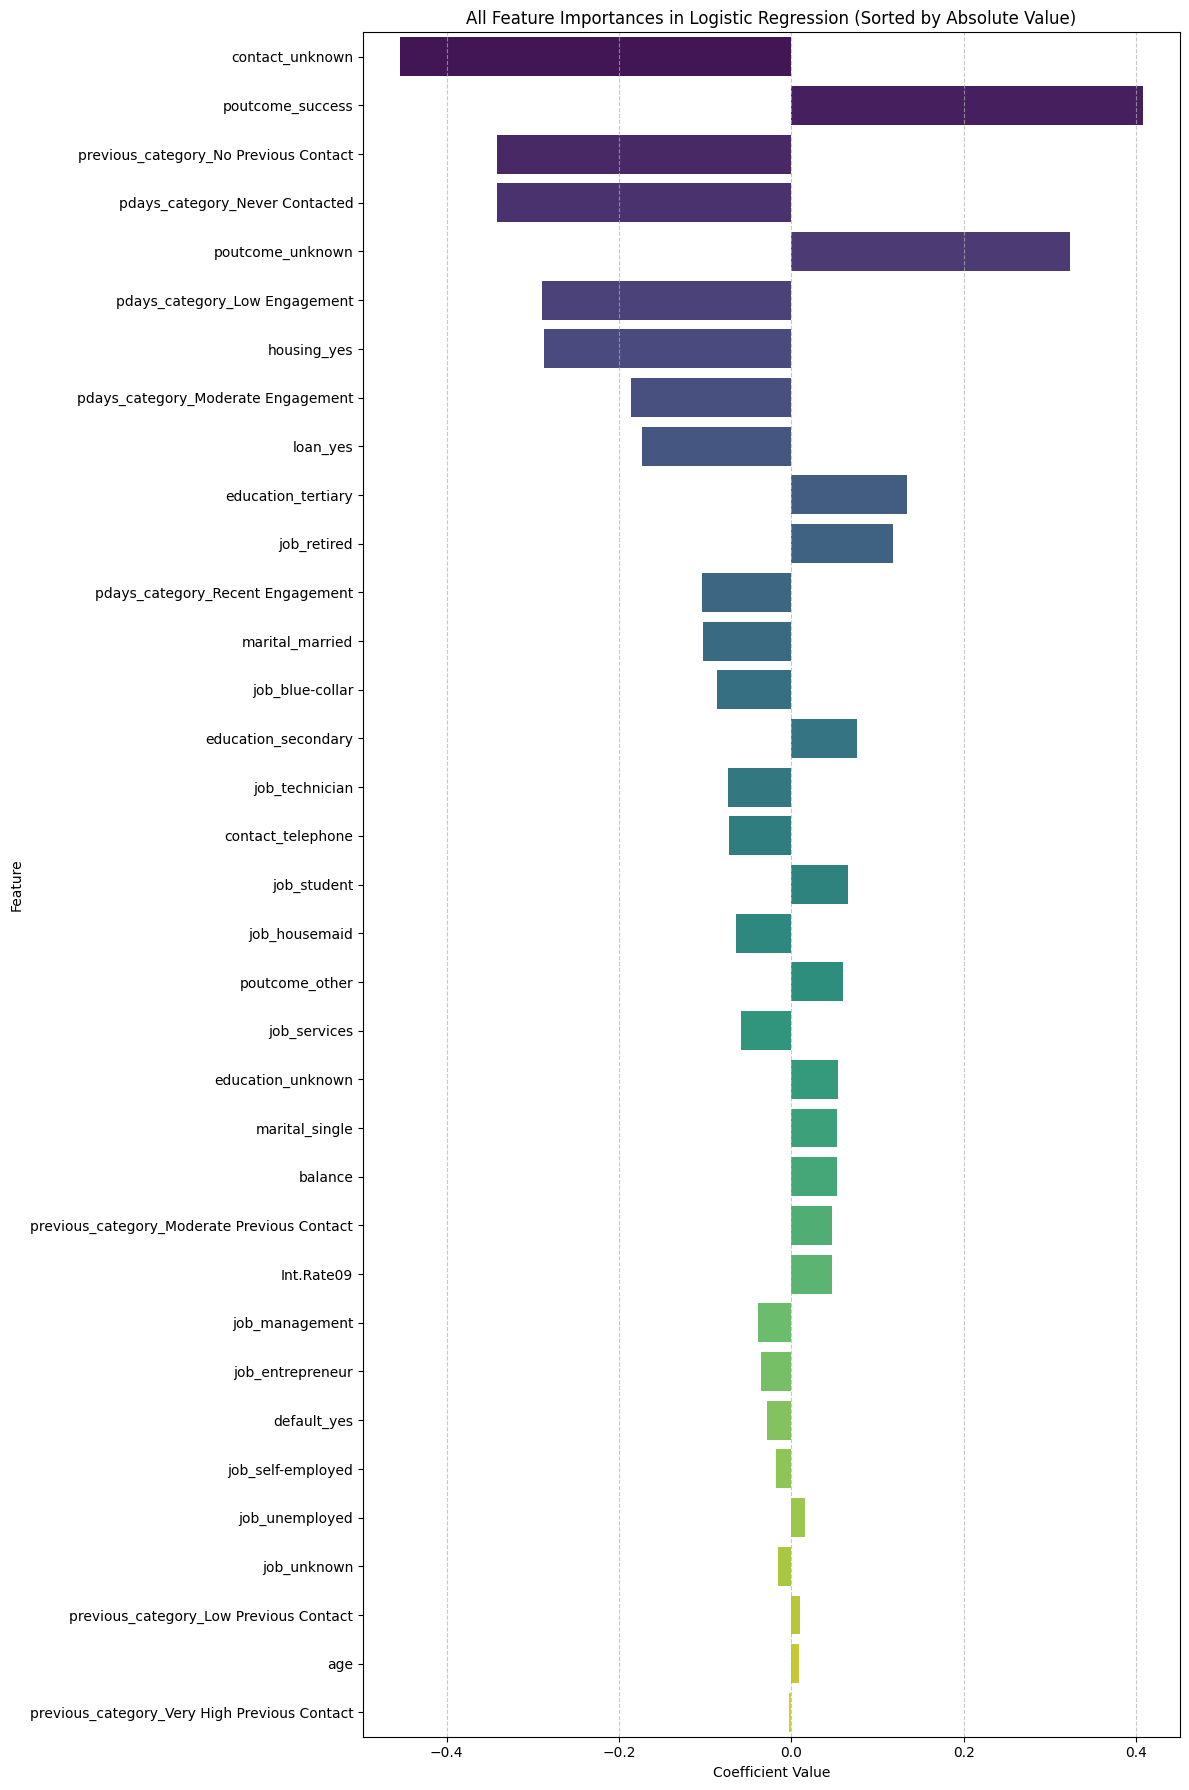

In [ ]:


# Visualize all features sorted by absolute coefficient value
# Adjust figure size to accommodate all features
plt.figure(figsize=(12, 18)) # Increased height to fit all features
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('All Feature Importances in Logistic Regression (Sorted by Absolute Value)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# n_estimators is the number of trees in the forest
# random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

# Make predictions on the scaled test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix for Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
display(pd.DataFrame(cm_rf, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")

Random Forest model trained successfully.

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      7985
           1       0.50      0.21      0.29      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.59      0.61      9043
weighted avg       0.86      0.88      0.86      9043


Confusion Matrix for Random Forest:


,Predicted 0,Predicted 1
Actual 0,7763,222
Actual 1,838,220



Random Forest Accuracy: 0.8828


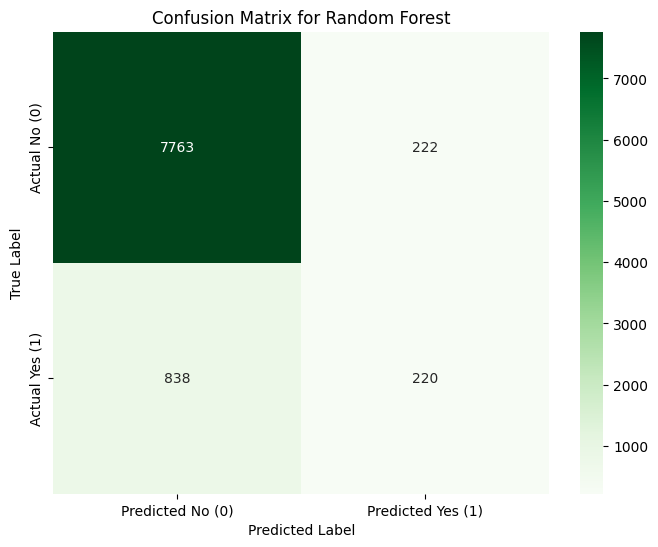

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Confusion Matrix as a heatmap for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Decision Tree Classifier
# random_state for reproducibility
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model using the scaled training data
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree model trained successfully.")

# Make predictions on the scaled test data
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix for Decision Tree:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
display(pd.DataFrame(cm_dt, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Accuracy: {accuracy_dt:.4f}")

Decision Tree model trained successfully.

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7985
           1       0.28      0.32      0.30      1058

    accuracy                           0.82      9043
   macro avg       0.59      0.60      0.60      9043
weighted avg       0.83      0.82      0.83      9043


Confusion Matrix for Decision Tree:


,Predicted 0,Predicted 1
Actual 0,7120,865
Actual 1,724,334



Decision Tree Accuracy: 0.8243


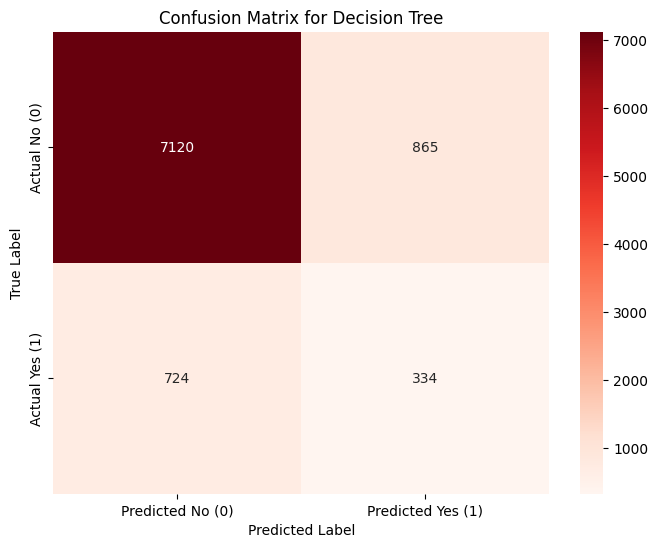

In [ ]:


# Plot the Confusion Matrix as a heatmap for Decision Tree
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Feature Importance Analysis for Decision Tree

In [ ]:
importances_dt = dt_model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_dt
})

# Sort features by importance
feature_importance_dt = feature_importance_dt.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features for Decision Tree:")
display(feature_importance_dt.head(10))

Top 10 Most Important Features for Decision Tree:


,Feature,Importance
1,balance,0.349099
0,age,0.184069
25,poutcome_success,0.093021
2,Int.Rate09,0.090838
16,education_secondary,0.021166
17,education_tertiary,0.018047
11,job_technician,0.016610
3,job_blue-collar,0.016350
6,job_management,0.015508
14,marital_married,0.014636


/tmp/ipykernel_816/2755439506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_dt.head(20), palette='Greens_d')


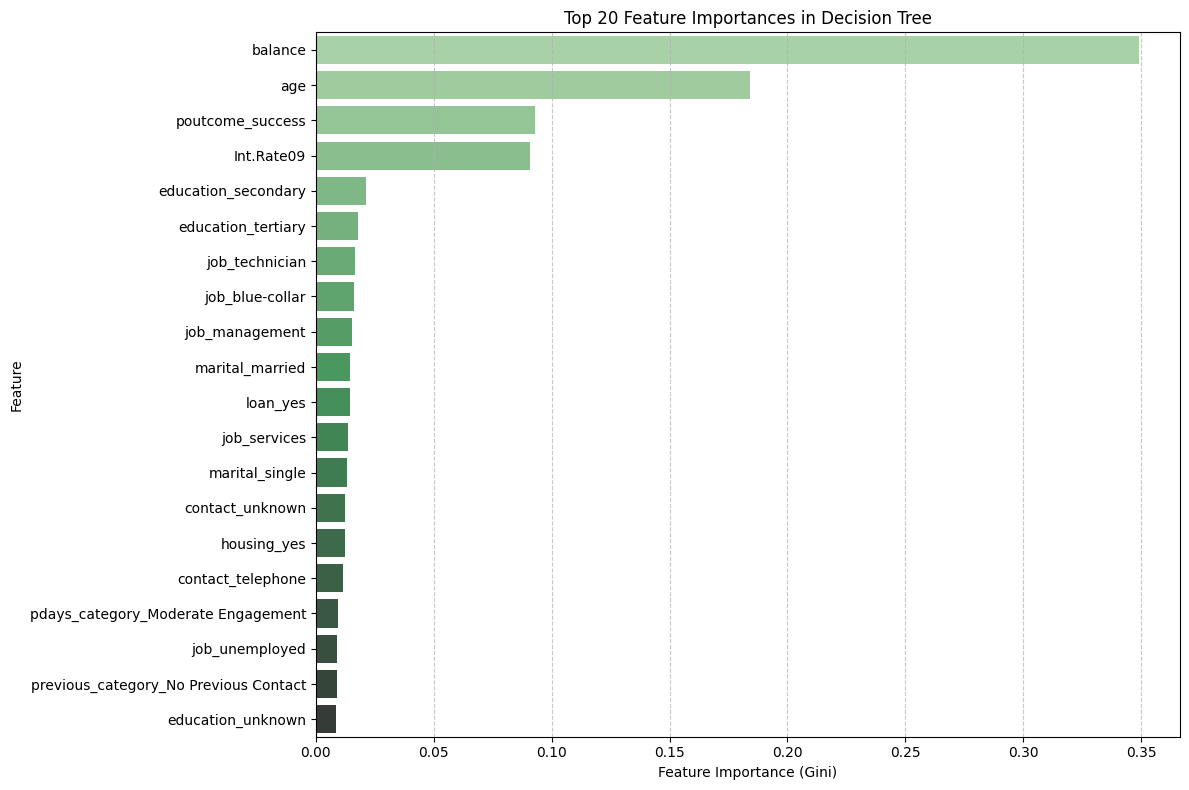

In [ ]:


# Visualize the top 20 most important features for Decision Tree
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_dt.head(20), palette='Greens_d')
plt.title('Top 20 Feature Importances in Decision Tree')
plt.xlabel('Feature Importance (Gini)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost Model

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the XGBoost Classifier
# Use 'objective="binary:logistic"' for binary classification
# 'use_label_encoder=False' and 'eval_metric="logloss"' are for suppressing warnings in newer versions
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Train the model using the scaled training data (without SMOTE for initial evaluation)
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost model trained successfully.")

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix for XGBoost:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
display(pd.DataFrame(cm_xgb, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Accuracy: {accuracy_xgb:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:04:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully.

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.57      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043


Confusion Matrix for XGBoost:


,Predicted 0,Predicted 1
Actual 0,7799,186
Actual 1,813,245



XGBoost Accuracy: 0.8895


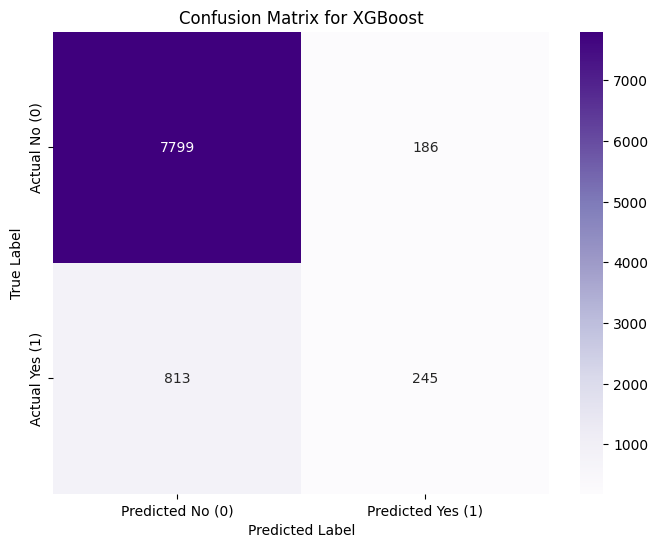

In [ ]:

# Plot the Confusion Matrix as a heatmap for XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### LightGBM Model


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the LightGBM Classifier
# Use 'objective="binary"' for binary classification
lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42)

# Train the model using the scaled training data
lgbm_model.fit(X_train_scaled, y_train)

print("LightGBM model trained successfully.")

# Make predictions on the scaled test data
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for LightGBM:")
print(classification_report(y_test, y_pred_lgbm))

print("\nConfusion Matrix for LightGBM:")
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
display(pd.DataFrame(cm_lgbm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
print(f"\nLightGBM Accuracy: {accuracy_lgbm:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
LightGBM model trained successfully.

Classification Report for LightGBM:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.64      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg      

,Predicted 0,Predicted 1
Actual 0,7861,124
Actual 1,838,220



LightGBM Accuracy: 0.8936


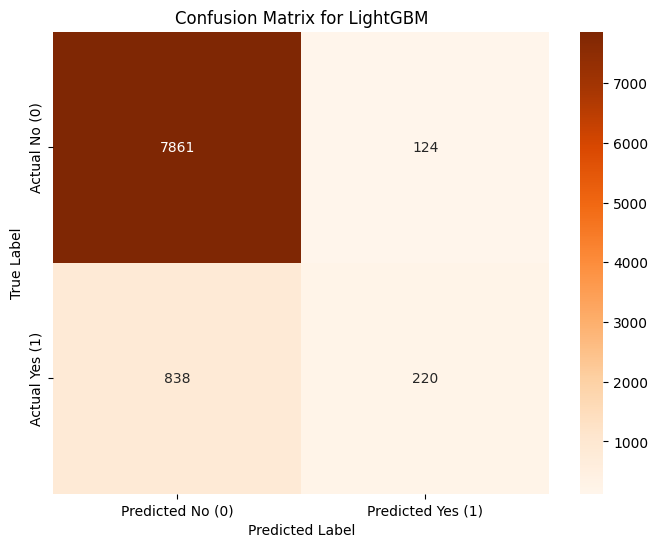

In [ ]:

# Plot the Confusion Matrix as a heatmap for LightGBM
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for LightGBM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Feature Importance Analysis for LightGBM



In [ ]:
importances_lgbm = lgbm_model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_lgbm = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_lgbm
})

# Sort features by importance
feature_importance_lgbm = feature_importance_lgbm.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features for LightGBM:")
display(feature_importance_lgbm.head(10))

Top 10 Most Important Features for LightGBM:


,Feature,Importance
1,balance,824
0,age,625
2,Int.Rate09,489
20,housing_yes,95
14,marital_married,77
17,education_tertiary,66
16,education_secondary,63
22,contact_telephone,63
25,poutcome_success,56
11,job_technician,51


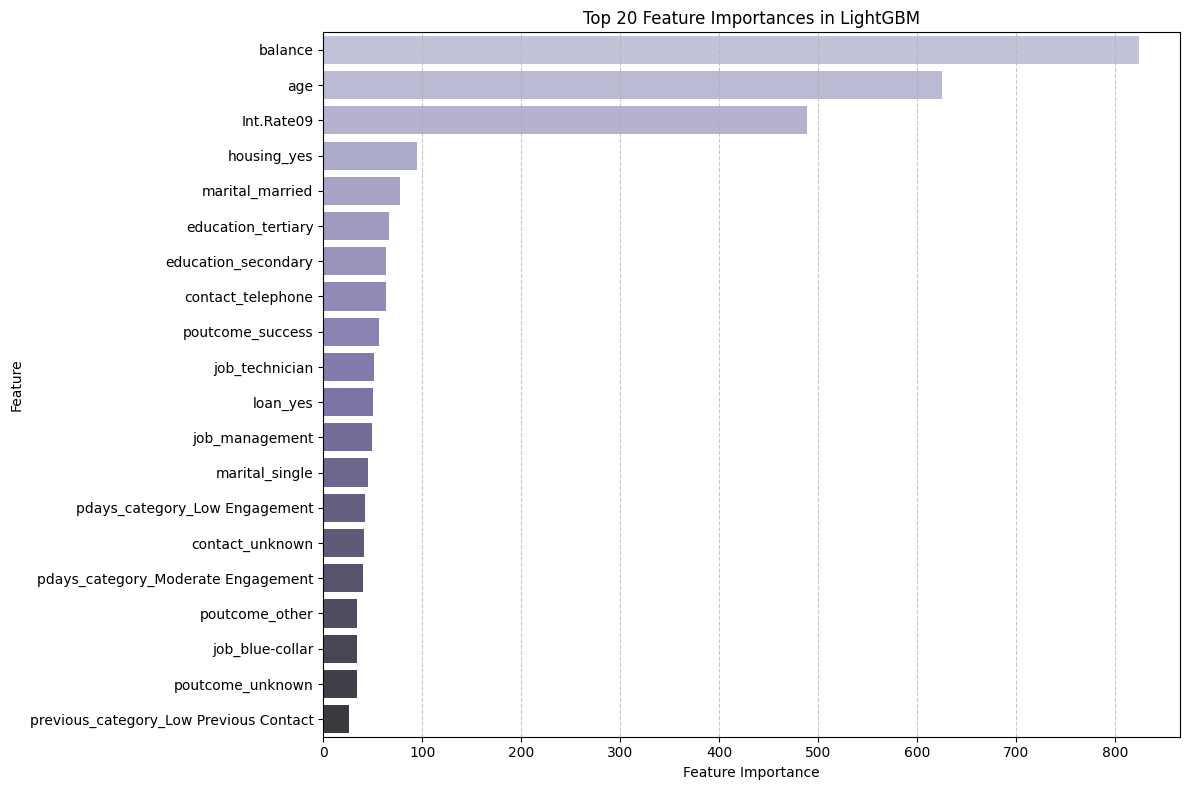

In [ ]:

# Visualize the top 20 most important features for LightGBM
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm.head(20), palette='Purples_d', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances in LightGBM')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization of All Feature Importances (LightGBM)



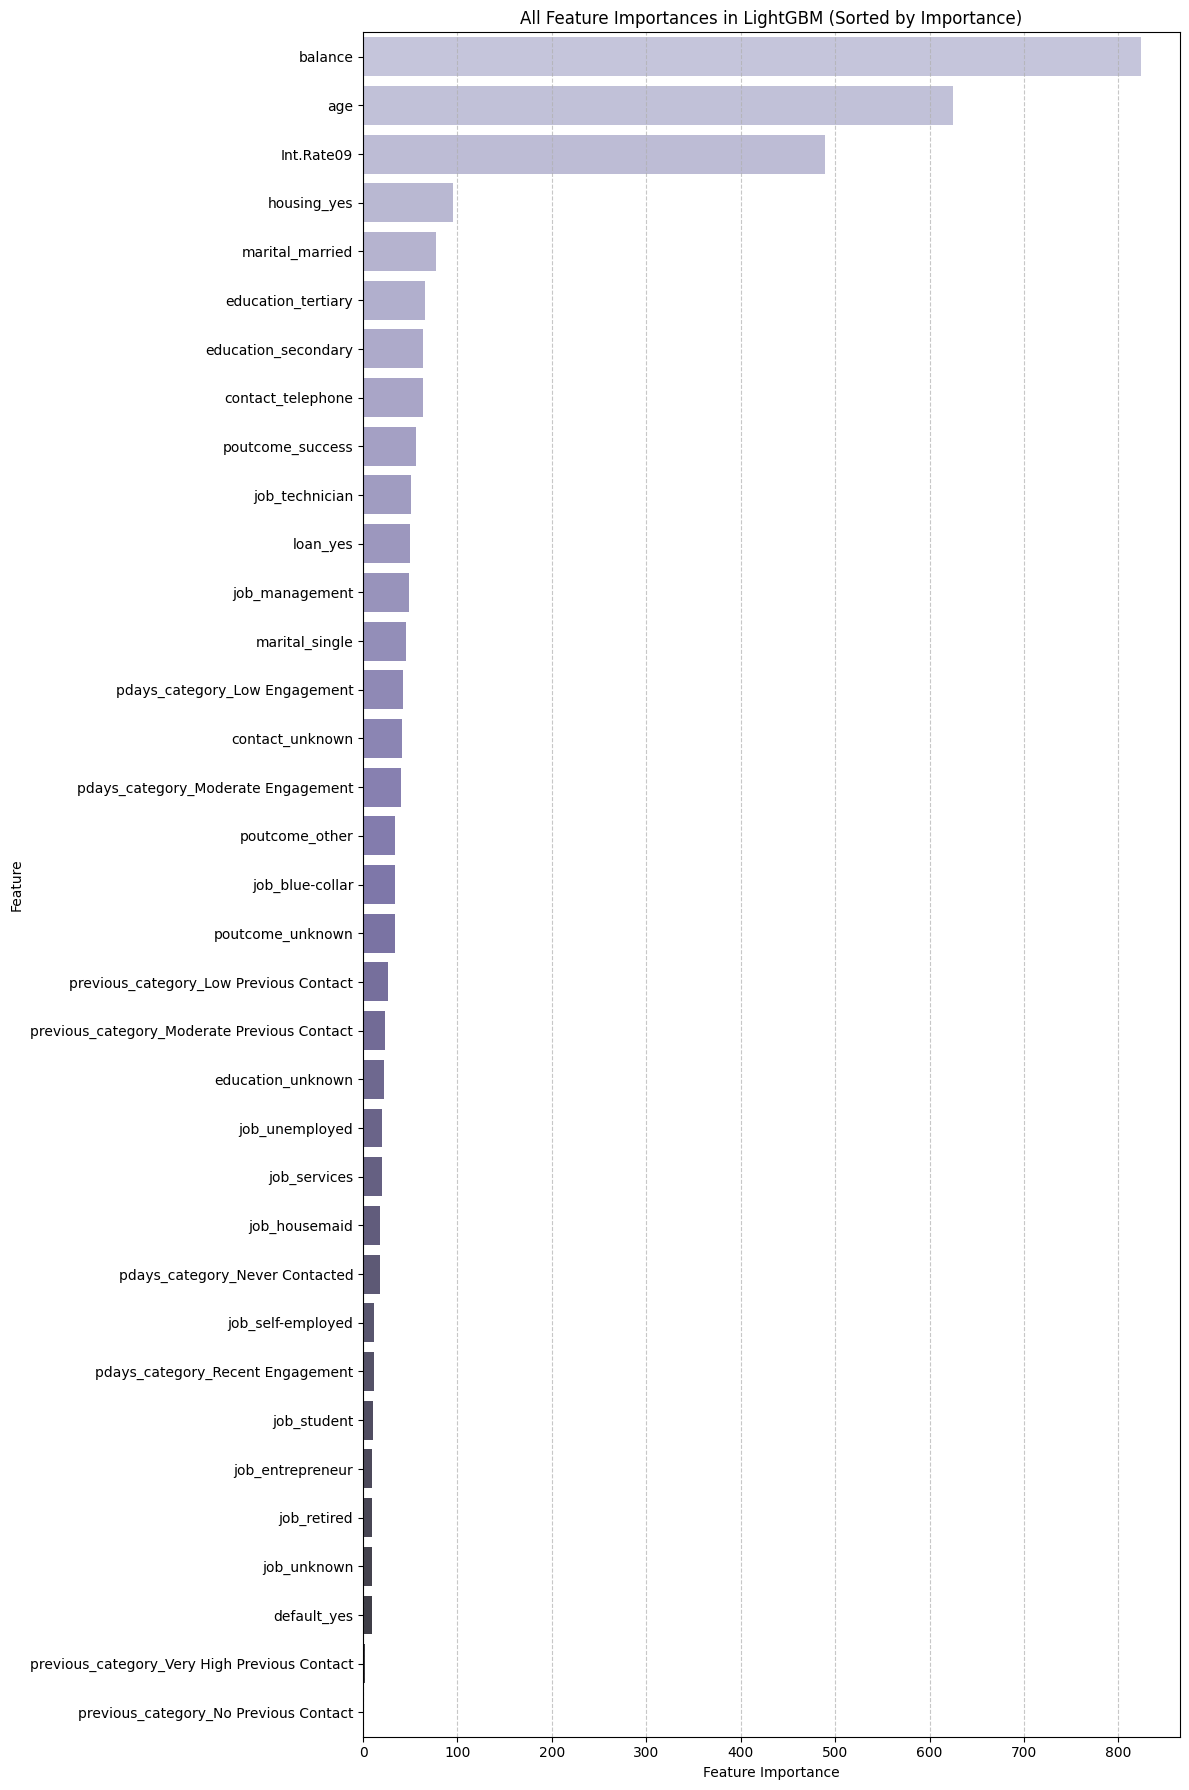

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize all features sorted by importance for LightGBM
plt.figure(figsize=(12, 18)) # Increased height to fit all features
sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm, palette='Purples_d', hue='Feature', legend=False)
plt.title('All Feature Importances in LightGBM (Sorted by Importance)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Class Weighting Analysis



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Logistic Regression model with class_weight='balanced'
log_reg_model_weighted = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Train the model using the scaled training data
log_reg_model_weighted.fit(X_train_scaled, y_train)

print("Logistic Regression model trained with class weighting successfully.")

# Make predictions on the scaled test data
y_pred_weighted = log_reg_model_weighted.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for Logistic Regression with Class Weighting:")
print(classification_report(y_test, y_pred_weighted))

print("\nConfusion Matrix for Logistic Regression with Class Weighting:")
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
display(pd.DataFrame(cm_weighted, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
print(f"\nAccuracy with Class Weighting: {accuracy_weighted:.4f}")

Logistic Regression model trained with class weighting successfully.

Classification Report for Logistic Regression with Class Weighting:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      7985
           1       0.23      0.63      0.33      1058

    accuracy                           0.70      9043
   macro avg       0.58      0.67      0.57      9043
weighted avg       0.85      0.70      0.75      9043


Confusion Matrix for Logistic Regression with Class Weighting:


,Predicted 0,Predicted 1
Actual 0,5688,2297
Actual 1,389,669



Accuracy with Class Weighting: 0.7030


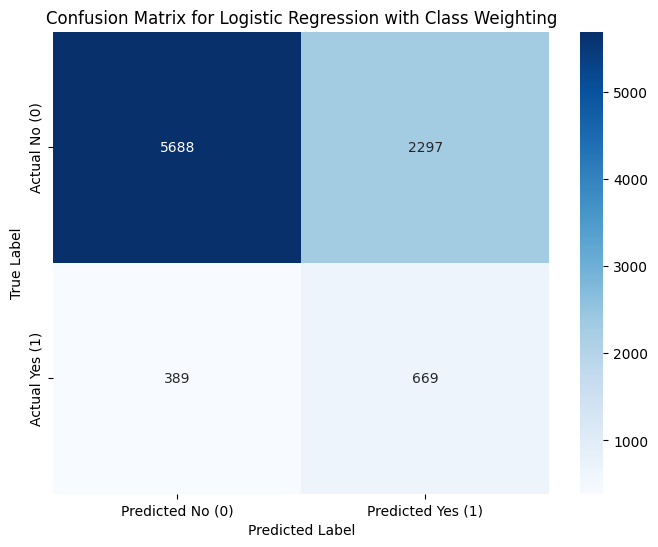

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Confusion Matrix as a heatmap for Logistic Regression with Class Weighting
plt.figure(figsize=(8, 6))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Logistic Regression with Class Weighting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison: Logistic Regression (Original vs. Class Weighted)



In [ ]:
print("Original Logistic Regression Model Performance:")
print(classification_report(y_test, y_pred))

print("\nLogistic Regression Model with Class Weighting Performance:")
print(classification_report(y_test, y_pred_weighted))

# For easier comparison:
print("\nAccuracy - Original: {:.4f}, Weighted: {:.4f}".format(accuracy, accuracy_weighted))

# Extracting recall for class 1 (minority class) from reports
report_original = classification_report(y_test, y_pred, output_dict=True)
report_weighted = classification_report(y_test, y_pred_weighted, output_dict=True)

recall_original_class1 = report_original['1']['recall']
recall_weighted_class1 = report_weighted['1']['recall']

print("Recall (Class 1) - Original: {:.4f}, Weighted: {:.4f}".format(recall_original_class1, recall_weighted_class1))

Original Logistic Regression Model Performance:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.68      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043


Logistic Regression Model with Class Weighting Performance:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      7985
           1       0.23      0.63      0.33      1058

    accuracy                           0.70      9043
   macro avg       0.58      0.67      0.57      9043
weighted avg       0.85      0.70      0.75      9043


Accuracy - Original: 0.8940, Weighted: 0.7030
Recall (Class 1) - Original: 0.1758, Weighted: 0.6323


### Decision Tree Model with Class Weighting



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Decision Tree Classifier with class_weight='balanced'
dt_model_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Train the model
dt_model_weighted.fit(X_train_scaled, y_train)

print("Decision Tree model trained with class weighting successfully.")

# Make predictions on the scaled test data
y_pred_dt_weighted = dt_model_weighted.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for Decision Tree with Class Weighting:")
print(classification_report(y_test, y_pred_dt_weighted))

print("\nConfusion Matrix for Decision Tree with Class Weighting:")
cm_dt_weighted = confusion_matrix(y_test, y_pred_dt_weighted)
display(pd.DataFrame(cm_dt_weighted, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_dt_weighted = accuracy_score(y_test, y_pred_dt_weighted)
print(f"\nAccuracy with Class Weighting: {accuracy_dt_weighted:.4f}")

Decision Tree model trained with class weighting successfully.

Classification Report for Decision Tree with Class Weighting:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7985
           1       0.28      0.29      0.29      1058

    accuracy                           0.83      9043
   macro avg       0.59      0.60      0.60      9043
weighted avg       0.83      0.83      0.83      9043


Confusion Matrix for Decision Tree with Class Weighting:


,Predicted 0,Predicted 1
Actual 0,7188,797
Actual 1,746,312



Accuracy with Class Weighting: 0.8294


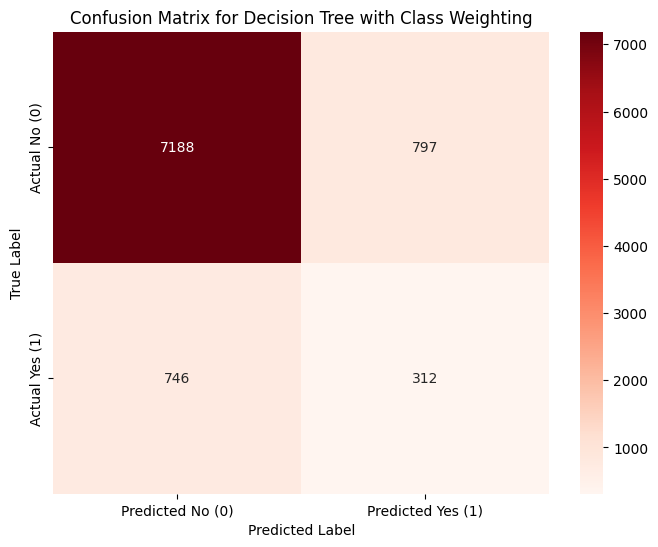

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Confusion Matrix as a heatmap for Decision Tree with Class Weighting
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_weighted, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Decision Tree with Class Weighting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison: Decision Tree (Original vs. Class Weighted)



In [ ]:
print("Original Decision Tree Model Performance:")
print(classification_report(y_test, y_pred_dt))

print("\nDecision Tree Model with Class Weighting Performance:")
print(classification_report(y_test, y_pred_dt_weighted))

# For easier comparison:
print("\nAccuracy - Original: {:.4f}, Weighted: {:.4f}".format(accuracy_dt, accuracy_dt_weighted))

# Extracting recall for class 1 (minority class) from reports
report_original_dt = classification_report(y_test, y_pred_dt, output_dict=True)
report_weighted_dt = classification_report(y_test, y_pred_dt_weighted, output_dict=True)

recall_original_class1_dt = report_original_dt['1']['recall']
recall_weighted_class1_dt = report_weighted_dt['1']['recall']

print("Recall (Class 1) - Original: {:.4f}, Weighted: {:.4f}".format(recall_original_class1_dt, recall_weighted_class1_dt))

Original Decision Tree Model Performance:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7985
           1       0.28      0.32      0.30      1058

    accuracy                           0.82      9043
   macro avg       0.59      0.60      0.60      9043
weighted avg       0.83      0.82      0.83      9043


Decision Tree Model with Class Weighting Performance:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7985
           1       0.28      0.29      0.29      1058

    accuracy                           0.83      9043
   macro avg       0.59      0.60      0.60      9043
weighted avg       0.83      0.83      0.83      9043


Accuracy - Original: 0.8243, Weighted: 0.8294
Recall (Class 1) - Original: 0.3157, Weighted: 0.2949


### Random Forest Model with Class Weighting



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the Random Forest Classifier with class_weight='balanced'
rf_model_weighted = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

# Train the model
rf_model_weighted.fit(X_train_scaled, y_train)

print("Random Forest model trained with class weighting successfully.")

# Make predictions on the scaled test data
y_pred_rf_weighted = rf_model_weighted.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for Random Forest with Class Weighting:")
print(classification_report(y_test, y_pred_rf_weighted))

print("\nConfusion Matrix for Random Forest with Class Weighting:")
cm_rf_weighted = confusion_matrix(y_test, y_pred_rf_weighted)
display(pd.DataFrame(cm_rf_weighted, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_rf_weighted = accuracy_score(y_test, y_pred_rf_weighted)
print(f"\nAccuracy with Class Weighting: {accuracy_rf_weighted:.4f}")

Random Forest model trained with class weighting successfully.

Classification Report for Random Forest with Class Weighting:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.52      0.20      0.29      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.59      0.62      9043
weighted avg       0.86      0.88      0.86      9043


Confusion Matrix for Random Forest with Class Weighting:


,Predicted 0,Predicted 1
Actual 0,7787,198
Actual 1,842,216



Accuracy with Class Weighting: 0.8850


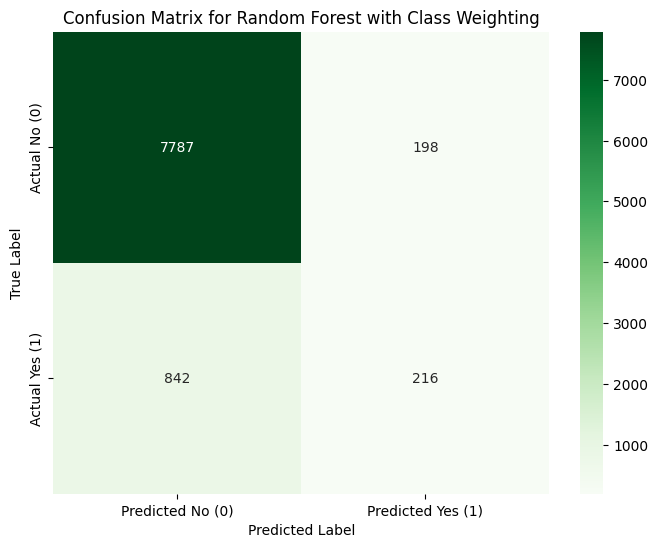

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Confusion Matrix as a heatmap for Random Forest with Class Weighting
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_weighted, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Random Forest with Class Weighting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison: Random Forest (Original vs. Class Weighted)



In [ ]:
print("Original Random Forest Model Performance:")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest Model with Class Weighting Performance:")
print(classification_report(y_test, y_pred_rf_weighted))

# For easier comparison:
print("\nAccuracy - Original: {:.4f}, Weighted: {:.4f}".format(accuracy_rf, accuracy_rf_weighted))

# Extracting recall for class 1 (minority class) from reports
report_original_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_weighted_rf = classification_report(y_test, y_pred_rf_weighted, output_dict=True)

recall_original_class1_rf = report_original_rf['1']['recall']
recall_weighted_class1_rf = report_weighted_rf['1']['recall']

print("Recall (Class 1) - Original: {:.4f}, Weighted: {:.4f}".format(recall_original_class1_rf, recall_weighted_class1_rf))

Original Random Forest Model Performance:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      7985
           1       0.50      0.21      0.29      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.59      0.61      9043
weighted avg       0.86      0.88      0.86      9043


Random Forest Model with Class Weighting Performance:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.52      0.20      0.29      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.59      0.62      9043
weighted avg       0.86      0.88      0.86      9043


Accuracy - Original: 0.8828, Weighted: 0.8850
Recall (Class 1) - Original: 0.2079, Weighted: 0.2042


### XGBoost Model with Class Weighting (`scale_pos_weight`)



In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate scale_pos_weight for XGBoost
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize the XGBoost Classifier with scale_pos_weight
xgb_model_weighted = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, scale_pos_weight=scale_pos_weight_value)

# Train the model
xgb_model_weighted.fit(X_train_scaled, y_train)

print("XGBoost model trained with class weighting (scale_pos_weight) successfully.")

# Make predictions on the scaled test data
y_pred_xgb_weighted = xgb_model_weighted.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for XGBoost with Class Weighting:")
print(classification_report(y_test, y_pred_xgb_weighted))

print("\nConfusion Matrix for XGBoost with Class Weighting:")
cm_xgb_weighted = confusion_matrix(y_test, y_pred_xgb_weighted)
display(pd.DataFrame(cm_xgb_weighted, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_xgb_weighted = accuracy_score(y_test, y_pred_xgb_weighted)
print(f"\nAccuracy with Class Weighting: {accuracy_xgb_weighted:.4f}")

Calculated scale_pos_weight: 7.55


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:04:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained with class weighting (scale_pos_weight) successfully.

Classification Report for XGBoost with Class Weighting:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88      7985
           1       0.31      0.56      0.40      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.70      0.64      9043
weighted avg       0.86      0.80      0.83      9043


Confusion Matrix for XGBoost with Class Weighting:


,Predicted 0,Predicted 1
Actual 0,6676,1309
Actual 1,462,596



Accuracy with Class Weighting: 0.8042


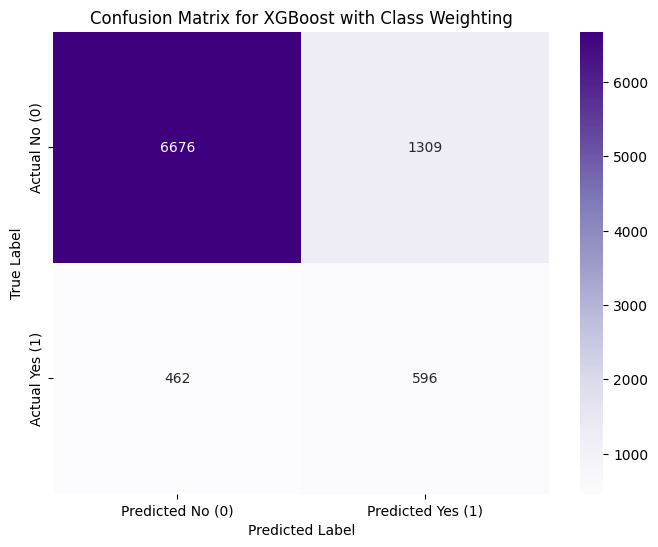

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Confusion Matrix as a heatmap for XGBoost with Class Weighting
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_weighted, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for XGBoost with Class Weighting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison: XGBoost (Original vs. Class Weighted)
Comparing the performance metrics of the original XGBoost model with the one trained using `scale_pos_weight`.

In [ ]:
print("Original XGBoost Model Performance:")
print(classification_report(y_test, y_pred_xgb))

print("\nXGBoost Model with Class Weighting Performance:")
print(classification_report(y_test, y_pred_xgb_weighted))

# For easier comparison:
print("\nAccuracy - Original: {:.4f}, Weighted: {:.4f}".format(accuracy_xgb, accuracy_xgb_weighted))

# Extracting recall for class 1 (minority class) from reports
report_original_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
report_weighted_xgb = classification_report(y_test, y_pred_xgb_weighted, output_dict=True)

recall_original_class1_xgb = report_original_xgb['1']['recall']
recall_weighted_class1_xgb = report_weighted_xgb['1']['recall']

print("Recall (Class 1) - Original: {:.4f}, Weighted: {:.4f}".format(recall_original_class1_xgb, recall_weighted_class1_xgb))

Original XGBoost Model Performance:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.57      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043


XGBoost Model with Class Weighting Performance:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88      7985
           1       0.31      0.56      0.40      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.70      0.64      9043
weighted avg       0.86      0.80      0.83      9043


Accuracy - Original: 0.8895, Weighted: 0.8042
Recall (Class 1) - Original: 0.2316, Weighted: 0.5633


### LightGBM Model with Class Weighting (`scale_pos_weight`)

Similar to XGBoost, LightGBM also provides the `scale_pos_weight` parameter to handle class imbalance. I will use the same calculated ratio of negative to positive instances for this model.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Using the same calculated scale_pos_weight_value from above
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# Initialize the LightGBM Classifier with scale_pos_weight
lgbm_model_weighted = lgb.LGBMClassifier(objective='binary', random_state=42, scale_pos_weight=scale_pos_weight_value)

# Train the model
lgbm_model_weighted.fit(X_train_scaled, y_train)

print("LightGBM model trained with class weighting (scale_pos_weight) successfully.")

# Make predictions on the scaled test data
y_pred_lgbm_weighted = lgbm_model_weighted.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report for LightGBM with Class Weighting:")
print(classification_report(y_test, y_pred_lgbm_weighted))

print("\nConfusion Matrix for LightGBM with Class Weighting:")
cm_lgbm_weighted = confusion_matrix(y_test, y_pred_lgbm_weighted)
display(pd.DataFrame(cm_lgbm_weighted, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

accuracy_lgbm_weighted = accuracy_score(y_test, y_pred_lgbm_weighted)
print(f"\nAccuracy with Class Weighting: {accuracy_lgbm_weighted:.4f}")

Calculated scale_pos_weight: 7.55
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
LightGBM model trained with class weighting (scale_pos_weight) successfully.

Classification Report for LightGBM with Class Weighting:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      7985
           1       0.32      0.61      0.42      1058

    accuracy                   

,Predicted 0,Predicted 1
Actual 0,6630,1355
Actual 1,417,641



Accuracy with Class Weighting: 0.8040


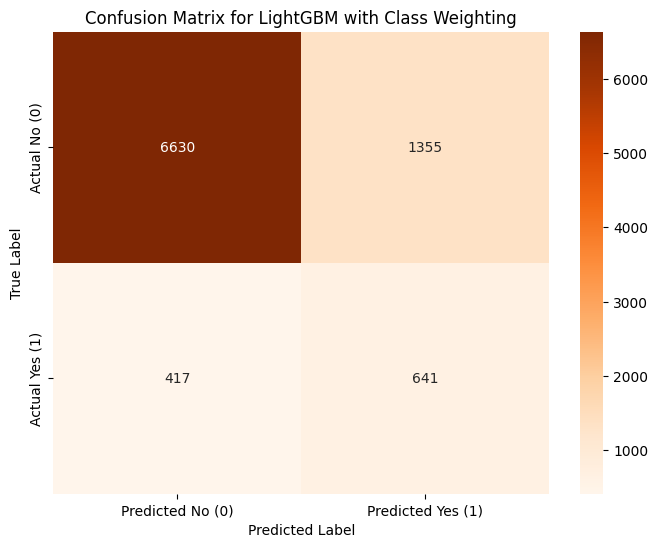

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Confusion Matrix as a heatmap for LightGBM with Class Weighting
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm_weighted, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for LightGBM with Class Weighting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison: LightGBM (Original vs. Class Weighted)

 Comparing the performance metrics of the original LightGBM model with the one trained using `scale_pos_weight`.

In [ ]:
print("Original LightGBM Model Performance:")
print(classification_report(y_test, y_pred_lgbm))

print("\nLightGBM Model with Class Weighting Performance:")
print(classification_report(y_test, y_pred_lgbm_weighted))

# For easier comparison:
print("\nAccuracy - Original: {:.4f}, Weighted: {:.4f}".format(accuracy_lgbm, accuracy_lgbm_weighted))

# Extracting recall for class 1 (minority class) from reports
report_original_lgbm = classification_report(y_test, y_pred_lgbm, output_dict=True)
report_weighted_lgbm = classification_report(y_test, y_pred_lgbm_weighted, output_dict=True)

recall_original_class1_lgbm = report_original_lgbm['1']['recall']
recall_weighted_class1_lgbm = report_weighted_lgbm['1']['recall']

print("Recall (Class 1) - Original: {:.4f}, Weighted: {:.4f}".format(recall_original_class1_lgbm, recall_weighted_class1_lgbm))

Original LightGBM Model Performance:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.64      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043


LightGBM Model with Class Weighting Performance:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      7985
           1       0.32      0.61      0.42      1058

    accuracy                           0.80      9043
   macro avg       0.63      0.72      0.65      9043
weighted avg       0.87      0.80      0.83      9043


Accuracy - Original: 0.8936, Weighted: 0.8040
Recall (Class 1) - Original: 0.2079, Weighted: 0.6059


### Feature Importance Analysis for LightGBM (Weighted)

Let's analyze the feature importances for the LightGBM model trained with class weighting. This will help us understand which features contribute most to the model's predictions when the minority class is given more emphasis.

In [ ]:
importances_lgbm_weighted = lgbm_model_weighted.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_lgbm_weighted = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_lgbm_weighted
})

# Sort features by importance
feature_importance_lgbm_weighted = feature_importance_lgbm_weighted.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features for LightGBM (Weighted):")
display(feature_importance_lgbm_weighted.head(10))

Top 10 Most Important Features for LightGBM (Weighted):


,Feature,Importance
1,balance,810
0,age,660
2,Int.Rate09,445
20,housing_yes,86
14,marital_married,76
21,loan_yes,75
17,education_tertiary,68
23,contact_unknown,63
16,education_secondary,56
22,contact_telephone,55


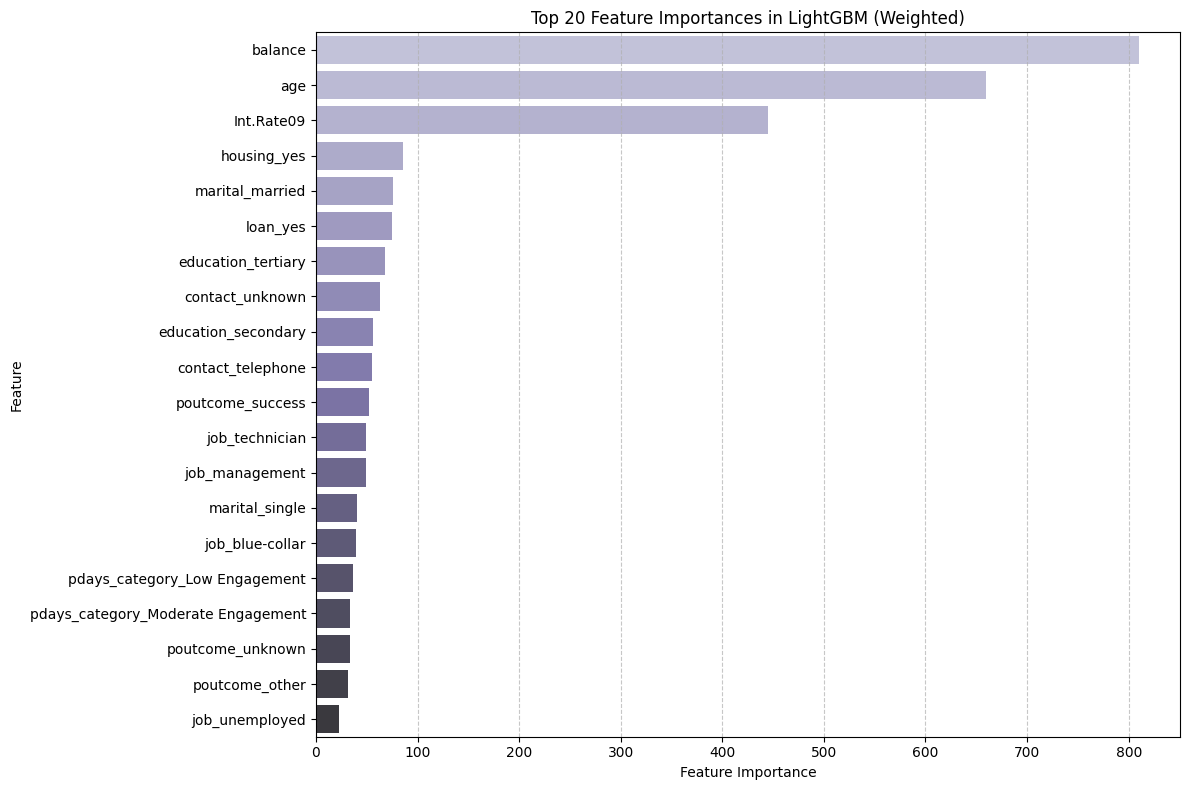

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 20 most important features for LightGBM (Weighted)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm_weighted.head(20), palette='Purples_d', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances in LightGBM (Weighted)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization of All Feature Importances (LightGBM Weighted)

To get a full understanding, I have visualize all features sorted by their importance for the class-weighted LightGBM model.

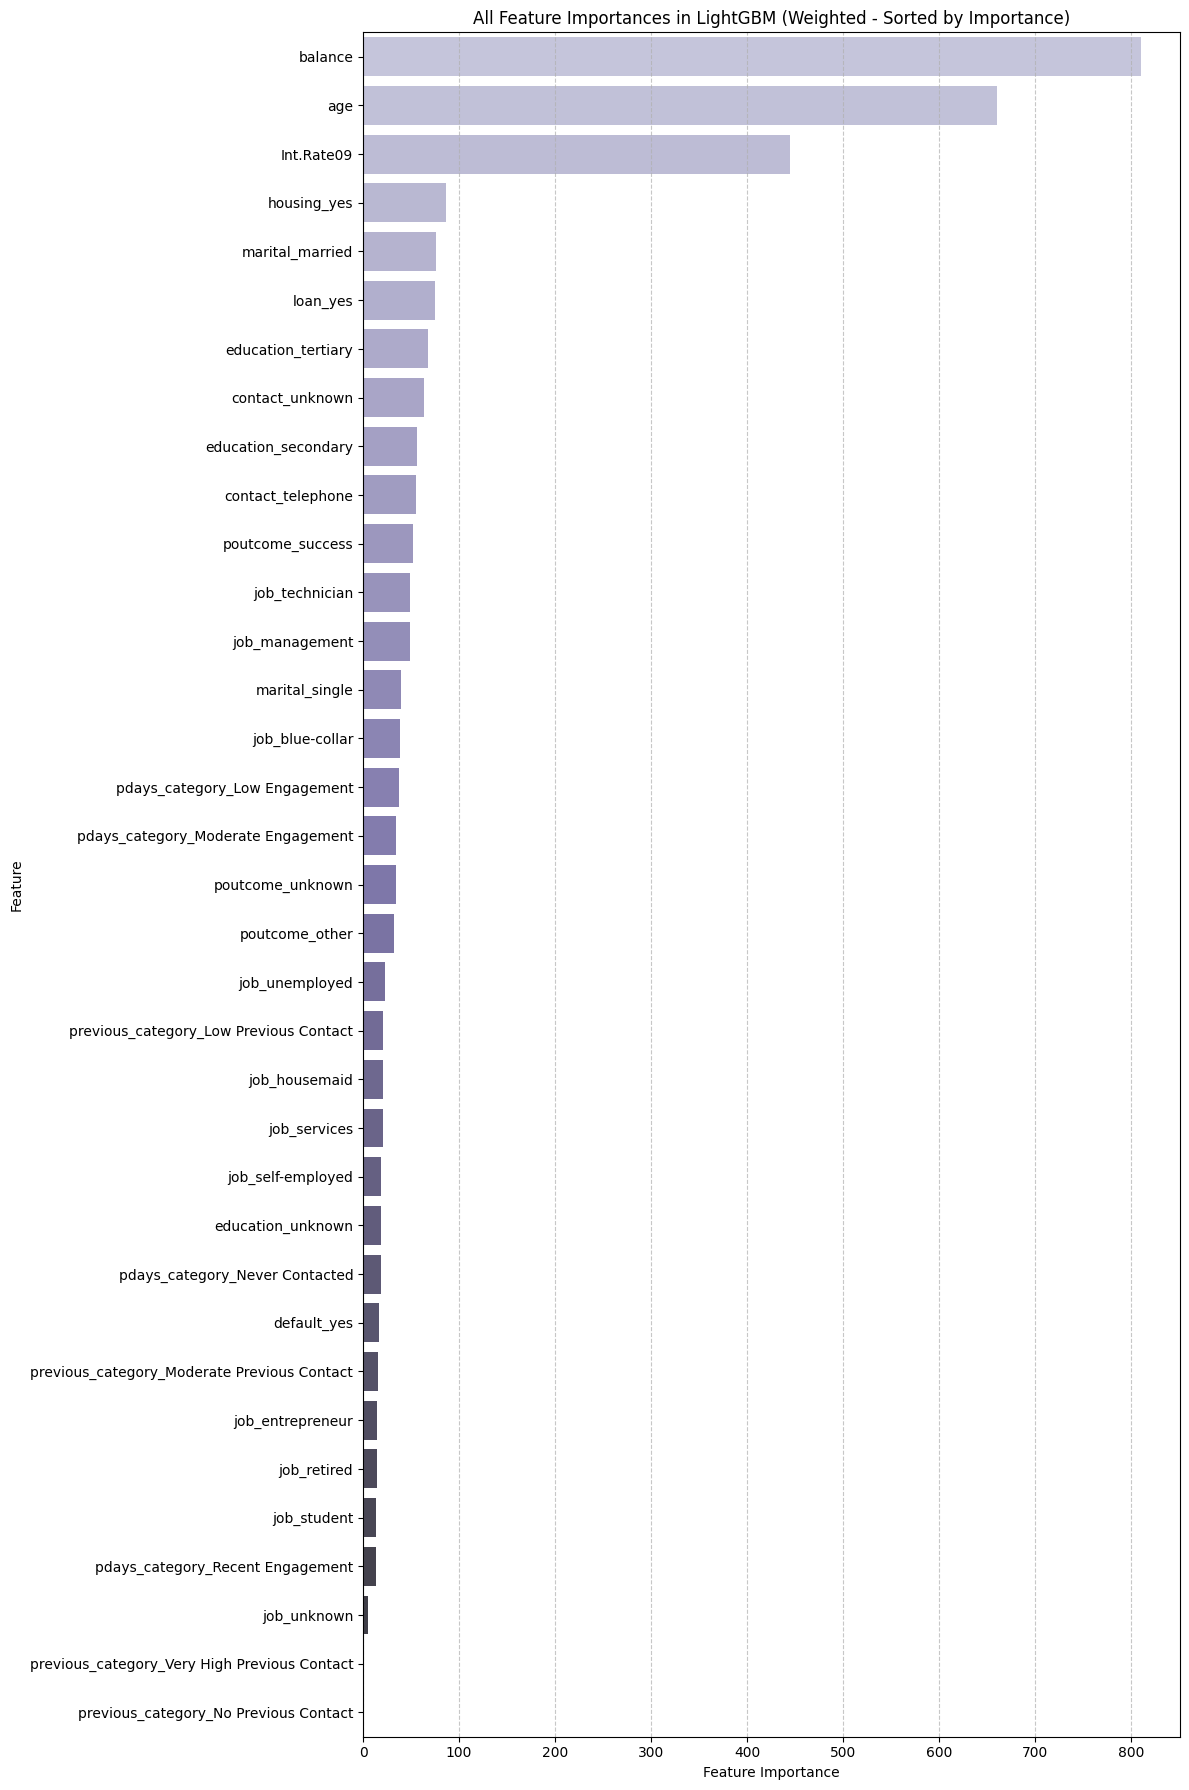

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize all features sorted by importance for LightGBM (Weighted)
plt.figure(figsize=(12, 18)) # Increased height to fit all features
sns.barplot(x='Importance', y='Feature', data=feature_importance_lgbm_weighted, palette='Purples_d', hue='Feature', legend=False)
plt.title('All Feature Importances in LightGBM (Weighted - Sorted by Importance)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### SHAP (SHapley Additive exPlanations) Analysis

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations by assigning each feature an importance value for a particular prediction. SHAP values tell us how much each feature contributes to the prediction of a specific instance, considering the interactions with other features.

For tree-based models like LightGBM, SHAP provides a highly insightful way to understand feature importance and impact on individual predictions. Since I trained a LightGBM model with class weighting, analyzing SHAP values will reveal how each feature drives the model's decision-making process, especially in the context of improving minority class recall.

In [ ]:
import shap

# Assuming lgbm_model_weighted is your trained LightGBM model
# And X_train_scaled is your scaled training data

# Create a SHAP explainer object. For tree models, TreeExplainer is efficient.
explainer = shap.TreeExplainer(lgbm_model_weighted)

# Calculate SHAP values for the test set
# It's recommended to use a subset of the data for faster computation if the dataset is large
# Here, we use a sample of X_test_scaled for illustration.
# For full analysis, you might want to use the entire X_test_scaled.

# Using a small sample for faster execution, adjust as needed
sample_size = min(1000, X_test_scaled.shape[0]) # Use up to 1000 samples or fewer if test set is smaller
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=42)

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


#### SHAP Summary Plot

The SHAP summary plot provides an overview of the feature importances and their impact direction (positive or negative) across the dataset. Each point on the plot represents a Shapley value for a feature and an instance. The position on the x-axis indicates the impact of that feature on the model's output prediction. The color represents the feature value (red for high, blue for low).

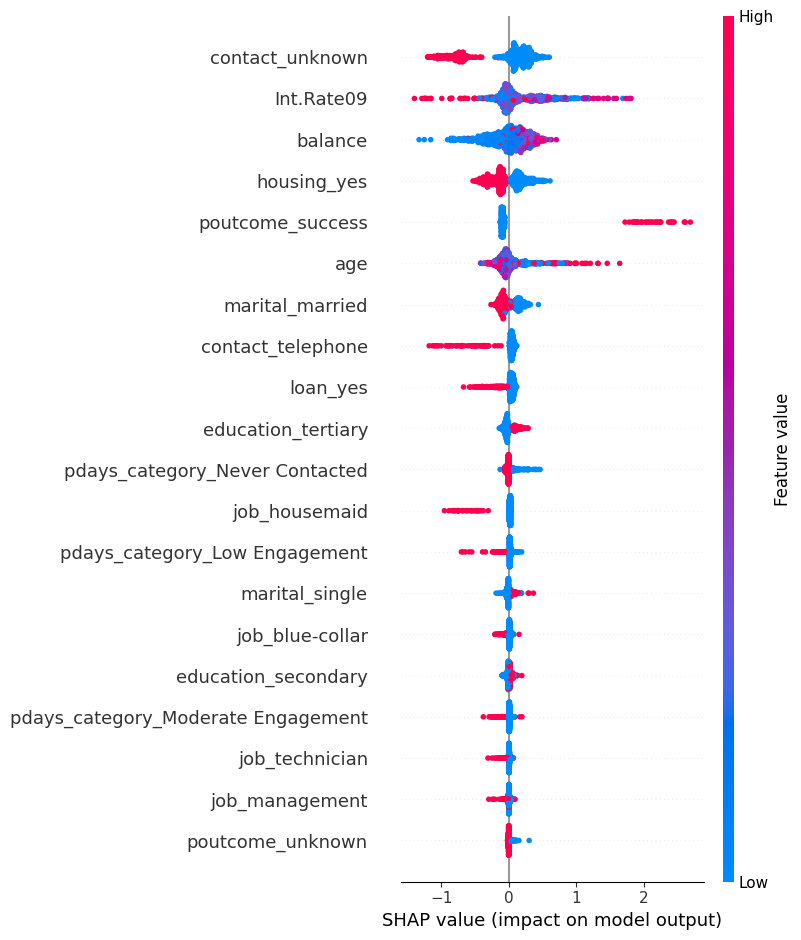

In [ ]:
# Summary plot for SHAP values
# `shap_values` is already a 2D array for the positive class, so we pass it directly
shap.summary_plot(shap_values, X_test_sample, plot_type="dot")

#### SHAP Dependence Plot

A SHAP dependence plot shows how the value of a single feature affects the prediction of the model. It plots the Shapley value of a feature against the actual value of that feature. The color usually represents an interacting feature, highlighting potential interaction effects.



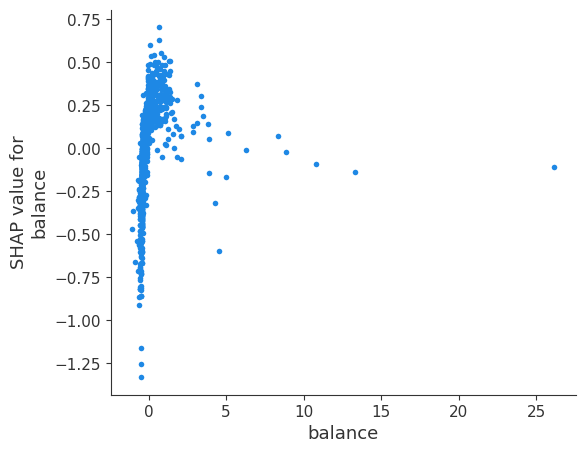

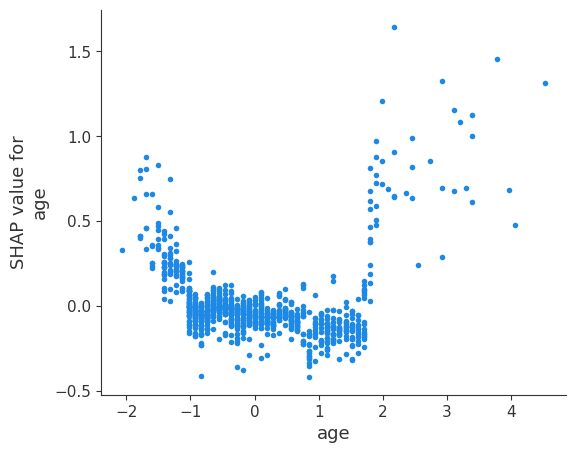

In [ ]:
# Get the top feature from the feature_importance_lgbm_weighted DataFrame
top_feature_lgbm_weighted = feature_importance_lgbm_weighted.iloc[0]['Feature']

# Create a SHAP dependence plot for the top feature
# `shap_values` is already a 2D array for the positive class, so we pass it directly
shap.dependence_plot(top_feature_lgbm_weighted, shap_values, X_test_sample, interaction_index=None)

# Optionally, create a dependence plot for another important feature (e.g., the second most important)
second_feature_lgbm_weighted = feature_importance_lgbm_weighted.iloc[1]['Feature']
shap.dependence_plot(second_feature_lgbm_weighted, shap_values, X_test_sample, interaction_index=None)

# You can also specify an interaction_index to see how another feature interacts with the main feature
# For example, to see the interaction between 'balance' and 'age'
# shap.dependence_plot('balance', shap_values, X_test_sample, interaction_index='age')

### ROC-AUC Score for LightGBM (Weighted)

In [ ]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_lgbm_weighted = lgbm_model_weighted.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba_lgbm_weighted)

print(f"ROC-AUC Score for LightGBM (Weighted): {roc_auc:.4f}")

ROC-AUC Score for LightGBM (Weighted): 0.7752


#### ROC Curve for LightGBM (Weighted)

<Figure size 800x600 with 0 Axes>

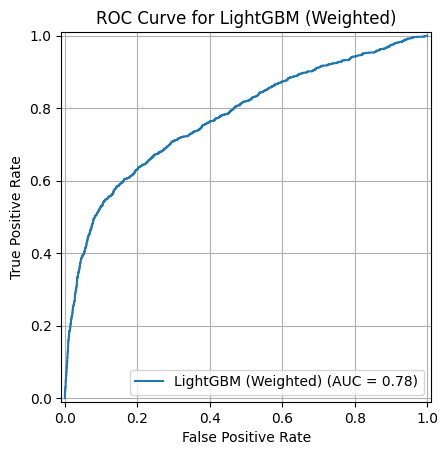

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Create the ROC Curve Display
roc_display = RocCurveDisplay.from_predictions(y_test, y_pred_proba_lgbm_weighted, name='LightGBM (Weighted)')

plt.title('ROC Curve for LightGBM (Weighted)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

In [ ]:
threshold = 0.5
# Convert probabilities to binary predictions based on the threshold
y_pred_lgbm_weighted_threshold = (y_pred_proba_lgbm_weighted >= threshold).astype(int)

# Count the number of customers flagged as likely subscribers (class 1)
num_likely_subscribers = sum(y_pred_lgbm_weighted_threshold == 1)

print(f"Number of customers flagged as likely subscribers by LightGBM (weighted) at threshold {threshold}: {num_likely_subscribers}")

Number of customers flagged as likely subscribers by LightGBM (weighted) at threshold 0.5: 1996


# # End of Analysis

This notebook contains all data preprocessing, feature engineering, classification modelling, model evaluation, and interpretability analyses used in this project.

Generative AI tools were used to assist with code development, debugging, and documentation. All code was reviewed, tested, modified where necessary, and executed by the author.